In [1]:
# import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import joblib

device = 'cuda' if torch.cuda.is_available() else 'cpu'

def seed_all(seed=0):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [2]:
# Load features and split and scale the dataset
df = pd.read_csv("../features_output_binned.csv")
X = df.drop(columns=["Label"]).values
y = df["Label"].values

# === Split & scale ===
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, "scaler.joblib")
print("✅ Saved scaler to scaler.joblib")

✅ Saved scaler to scaler.joblib


In [3]:
print(X_test_scaled.shape, y_test.shape)
print(X_train_scaled.shape, y_train.shape)
# print first 10 rows of the test set
print(X_test_scaled[:1])
print(y_test[:40])

(80, 36) (80,)
(320, 36) (320,)
[[ 0.91522758 -1.17901474 -0.90685083  0.97699368 -1.20668418 -1.2061198
  -0.56740134  1.35805739 -1.36681934  1.36681934  0.90166852 -1.07664702
   0.91692845  0.79366776  1.60739678 -1.0844063  -0.76538172  1.83015435
  -0.94747397 -2.01520233 -0.93985195 -0.0885344  -0.88753577  0.60317132
  -0.90432777  0.68038283 -0.90266696 -1.19282796 -0.86264674  0.50066992
  -0.88105022 -0.43179748 -0.89568301 -0.52124996 -0.88826517  3.26127548]]
[5 4 2 3 5 4 5 7 3 6 2 2 4 1 3 4 6 0 7 0 5 7 6 6 6 1 1 5 2 7 4 2 7 4 1 7 4
 7 0 3]


In [4]:
# Convert to tensors ===
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=16, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=16, shuffle=False)

In [5]:
class DeepMLP(nn.Module):
    def __init__(self, input_size=36, hidden_sizes=[128, 64, 32], output_size=8, p_dropout=0.3, device='cpu'):
        super().__init__()
        self.device = device

        layers = []
        in_feats = input_size
        for h in hidden_sizes:
            layers += [
                nn.Linear(in_feats, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(p_dropout)
            ]
            in_feats = h
        layers.append(nn.Linear(in_feats, output_size))
        self.net = nn.Sequential(*layers)
        self.to(device=device)
        self.lossfn = nn.CrossEntropyLoss()
        

    def forward(self, x):
        return self.net(x)
    
    def Train(self, epochs, optimizer, loader_train, loader_test, verbose=True, patience=10):
        best_loss = float('inf')  # Initialize best loss
        self.loss_train_log = []
        self.loss_test_log = []
        epoch_no_improvement = 0  # Counter for early stopping
        for epoch in range(epochs):
            self.train()
            for x, y in loader_train:
                x = x.to(self.device)
                y = y.to(self.device)
                optimizer.zero_grad()
                y_pred = self.forward(x)
                loss = self.lossfn(y_pred, y)
                loss.backward()
                optimizer.step()
            loss_train = self.evaluate(loader_train)
            loss_test = self.evaluate(loader_test)
            self.loss_train_log.append(loss_train)
            self.loss_test_log.append(loss_test)
            # Save the best model
            if loss_test < best_loss:
                epoch_no_improvement = 0      
                best_loss = loss_test
                torch.save(self.state_dict(), 'best_model.pth')  # 🔐 Save best model
                print(f"Best model saved with loss: {best_loss:.4f} at {epoch+1}")
            else:
                epoch_no_improvement += 1
                if epoch_no_improvement >= patience:
                    print(f"Early stopping at epoch {epoch+1} with no improvement.")
                    break
                
            if verbose:
                print(f"Epoch {epoch+1}/{epochs} | Train Loss: {self.loss_train_log[-1]:.4f} | Test Loss: {self.loss_test_log[-1]:.4f}")

    def evaluate(self, loader):
        self.eval()
        total_loss = 0
        with torch.no_grad():
            for x, y in loader:
                x = x.to(self.device)
                y = y.to(self.device)
                y_pred = self.forward(x)
                loss = self.lossfn(y_pred, y)
                total_loss += loss.item()
        return total_loss / len(loader)

In [6]:
model = DeepMLP(input_size=36, hidden_sizes=[256,128,64,32], output_size=8, p_dropout=0.3, device=device)
# also be extra‐sure you didn’t accidentally create it on CPU:
model = model.to(device)
print(model.device)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4, weight_decay=2e-5)
model.Train(epochs=200, optimizer=optimizer, loader_train=train_loader, loader_test=test_loader, patience=15)

cuda
Best model saved with loss: 2.0146 at 1
Epoch 1/200 | Train Loss: 2.0247 | Test Loss: 2.0146
Best model saved with loss: 1.8813 at 2
Epoch 2/200 | Train Loss: 1.8988 | Test Loss: 1.8813
Best model saved with loss: 1.7906 at 3
Epoch 3/200 | Train Loss: 1.8078 | Test Loss: 1.7906
Best model saved with loss: 1.7136 at 4
Epoch 4/200 | Train Loss: 1.7352 | Test Loss: 1.7136
Best model saved with loss: 1.6581 at 5
Epoch 5/200 | Train Loss: 1.6761 | Test Loss: 1.6581
Best model saved with loss: 1.6151 at 6
Epoch 6/200 | Train Loss: 1.6358 | Test Loss: 1.6151
Best model saved with loss: 1.5719 at 7
Epoch 7/200 | Train Loss: 1.5901 | Test Loss: 1.5719
Best model saved with loss: 1.5164 at 8
Epoch 8/200 | Train Loss: 1.5306 | Test Loss: 1.5164
Best model saved with loss: 1.4723 at 9
Epoch 9/200 | Train Loss: 1.4921 | Test Loss: 1.4723
Best model saved with loss: 1.4515 at 10
Epoch 10/200 | Train Loss: 1.4631 | Test Loss: 1.4515
Best model saved with loss: 1.4100 at 11
Epoch 11/200 | Train L

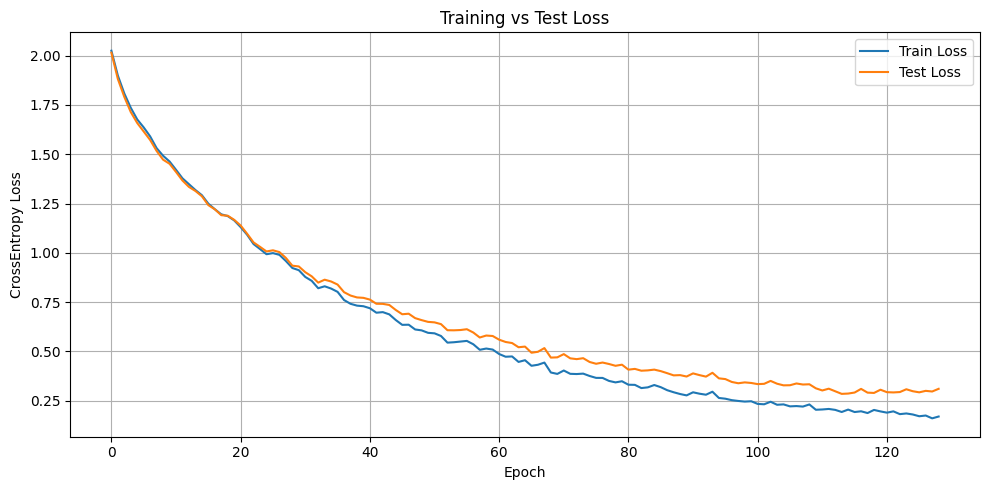

In [7]:
# Plot losses
plt.figure(figsize=(10,5))
plt.plot(model.loss_train_log, label='Train Loss')
plt.plot(model.loss_test_log, label='Test Loss')
plt.xlabel("Epoch")
plt.ylabel("CrossEntropy Loss")
plt.title("Training vs Test Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
from sklearn.metrics import accuracy_score

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        pred_labels = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(pred_labels)
        all_labels.extend(yb.numpy())

acc = accuracy_score(all_labels, all_preds)
print(f"✅ Final Test Accuracy: {acc * 100:.2f}%")

✅ Final Test Accuracy: 92.50%


In [9]:
raw_df = pd.read_csv("../raw.csv", header=None)       # replace with your path
X_raw = raw_df.values.astype("float32")
scaler: StandardScaler = joblib.load("scaler.joblib")
X_scaled = scaler.transform(X_raw)
X_tensor = torch.from_numpy(X_scaled)
X_tensor = X_tensor.to(device)
input_dim = X_tensor.shape[1]
model = DeepMLP(input_size=36, hidden_sizes=[256,128,64,32], output_size=8, p_dropout=0.3, device=device)
print(model.device)
model.load_state_dict(torch.load("best_model.pth", map_location="cpu"))
model.eval()

with torch.no_grad():
    logits = model(X_tensor)
    preds = torch.argmax(logits, dim=1).cpu().numpy()  # <-- move to CPU first

print(f"Predictions shape: {preds.shape}")
print(f"Predictions: {preds[:10]}")  # Print first 10 predictions


cuda
Predictions shape: (4,)
Predictions: [3 1 5 3]
